# Реконструкция каскадного распада

## Состав выборки

В работе два варианта состава семейства:

| Вариант | Объекты | Назначение |
|---|---|---|
| **17 объектов** | HCM ∩ K/L | Строгий состав — основные результаты |
| **18 объектов** | + `2014WE584` (только K/L) | Проверка устойчивости результатов |

Переключение через одну строку в ячейке ниже. Файл результата называется `summary_{N}_evolution.csv`, так что оба варианта живут рядом и не перетирают друг друга.

## 7 этапов пайплайна

0. **Расчёт таблицы парных сближений** — все комбинации сценариев осей.
1. **Загрузка и канонизация пар** — общий ключ независимо от порядка `id`.
2. **Быстрый индекс** по `(id, ось)` для O(1)-доступа к строке `summary`.
3. **Глобальное согласование осей** — итеративное распространение от 5 фиксированных объектов.
4. **Финальная переоценка пар** при назначенных осях (один сценарий на пару).
5. **Кластеризация по эпохам** через иерархическую кластеризацию по $T_{\rho_2}$.
6. **Дерево каскада** через минимальное $\rho_2$-расстояние от корня.
7. **Выгрузка таблиц** для разделов 4.2–4.4 + визуализация.


## Этап 0a. Состав выборки и общие константы

Здесь — единственное место, где задаётся состав семейства. Всё остальное автоматически подстраивается под `ASTEROID_IDS`.


In [2]:
# === Состав выборки ===

# 17 объектов: HCM ∩ K/L (строгий состав)
IDS_17 = ["14627", "126761", "224559", "256124", "434002", "476673",
          "2009UL13", "778121", "653857", "804185",
          "2016CS377", "2017UY114", "679223", "2020UZ20", "2021TU55",
          "2019VE44", "2022SA160"]

# 18 объектов: добавлен 2014WE584 (прошёл только K/L, но не HCM-ядро)
IDS_18 = IDS_17 + ["2014WE584"]

# >>> Переключатель состава <<<
ASTEROID_IDS = IDS_17           # строгий состав
# ASTEROID_IDS = IDS_18         # для проверки устойчивости с 2014WE584

# Объекты с известной из наблюдений ориентацией оси
FIXED_IDS = ["14627", "126761", "224559", "256124", "434002"]
'''
14627 - plus (на север) // https://damit.cuni.cz/projects/damit/
126761 - 

'''
SCENARIOS = ["nominal", "nominal_plus", "nominal_minus", "nominal_plane"]

# Имена файлов результата подстраиваются под размер выборки
N_OBJECTS  = len(ASTEROID_IDS)
SUMMARY_CSV = f"summary_{N_OBJECTS}_evolution.csv"

ROOT = "14627"
CANDIDATE_AXES = ["nominal_plus", "nominal_minus", "nominal_plane"]

AXIS_LABEL = {
    "nominal":       "Определено ранее",
    "nominal_plus":  "Ось на север (N)",
    "nominal_minus": "Ось на юг (S)",
    "nominal_plane": "Ось в плоскости эклиптики (P)",
}

# Пороги отбора надёжных пар
RHO2_MAX    = 0.05    # порог метрики Холшевникова
F_MIN_MAX   = 0.4     # порог сглаженного f(-T) в градусах
DELTA_T_MAX = 0.1     # порог |T_rho2 - T_angles| в Млн лет
T_MIN       = 1e-5    # отсечение нулевых возрастов

print(f"Выборка: {N_OBJECTS} объектов "
      f"({'строгий состав' if N_OBJECTS == 17 else 'с 2014WE584'})")
print(f"Файл таблицы парных сближений: {SUMMARY_CSV}")


Выборка: 17 объектов (строгий состав)
Файл таблицы парных сближений: summary_17_evolution.csv


## Этап 0b. Расчёт таблицы парных сближений

Перебор всех пар $(X, Y) \in \binom{N}{2}$. Для не-фиксированных объектов перебираются 4 сценария ориентации оси (`nominal`, `plus`, `minus`, `plane`); для фиксированных — только `nominal`.

Для каждой комбинации:
1. Загружаются ряды кеплеровских элементов из `{scenario}/vast_kep_xyz_{id}.txt`.
2. Считаются разности $\Delta\Omega(t)$ и $\Delta\omega(t)$ со сглаживанием скользящим средним (окно 100 шагов) — фильтрация короткопериодических возмущений от планет.
3. Считается метрика Холшевникова $\rho_2(t)$ и тоже сглаживается.
4. Находятся два момента: $T_{\rho_2}$ (минимум $\rho_2$) и $T_{\Delta\Omega,\Delta\omega}$ (минимум $f = \sqrt{\Delta\Omega^2 + \Delta\omega^2}$).
5. Записывается строка с обоими временами, $\Delta T$, $\rho_{2,\min}$, $f_{\min}$ и флагом `is_valid` ($f_{\min} < 0{,}4°$).

Если файл `SUMMARY_CSV` уже существует, ячейку можно пропустить — данные подгрузятся в этапе 1.

⚠️ Эта ячейка предполагает, что текущий каталог содержит подкаталоги `nominal/`, `nominal_plus/`, `nominal_minus/`, `nominal_plane/` с файлами `vast_kep_xyz_*.txt`.


In [3]:
# === Расчёт таблицы парных сближений ===
import os
from itertools import combinations
import numpy as np
import pandas as pd

WINDOW_SIZE = 100  # шаг сглаживания (фильтрует короткопериодические возмущения от планет)

def running_mean(x, n):
    return np.convolve(x, np.ones(n) / n, mode='valid')

def calc_rho2(a1, e1, i1, node1, per1, a2, e2, i2, node2, per2):
    # Метрика Холшевникова rho2 — мера близости орбит в 5-мерном пространстве элементов
    p1 = a1 * (1 - e1**2)
    p2 = a2 * (1 - e2**2)
    cos_I = np.cos(i1) * np.cos(i2) + np.sin(i1) * np.sin(i2) * np.cos(node1 - node2)
    cos_P = np.cos(per1 - per2)
    rho2_sq = ((1 + e1**2) * p1 + (1 + e2**2) * p2
               - 2 * np.sqrt(p1 * p2) * (e1 * e2 * cos_P + cos_I))
    return np.sqrt(np.maximum(rho2_sq, 0))

results = []
counter = 0
missing = 0

print(f"Перебор пар для {N_OBJECTS} объектов...")

for id1, id2 in combinations(ASTEROID_IDS, 2):
    scens1 = ["nominal"] if id1 in FIXED_IDS else SCENARIOS
    scens2 = ["nominal"] if id2 in FIXED_IDS else SCENARIOS

    for s1 in scens1:
        for s2 in scens2:
            path1 = os.path.join(s1, f"vast_kep_xyz_{id1}.txt")
            path2 = os.path.join(s2, f"vast_kep_xyz_{id2}.txt")

            if not (os.path.exists(path1) and os.path.exists(path2)):
                missing += 1
                continue

            try:
                # 0:t, 1:a, 2:e, 3:i, 4:node, 5:per, 15:h, 16:k, 17:p, 18:q
                cols = [0, 1, 2, 3, 4, 5, 15, 16, 17, 18]
                d1 = pd.read_csv(path1, sep=r'\s+', skiprows=1,
                                 header=None, usecols=cols).values
                d2 = pd.read_csv(path2, sep=r'\s+', skiprows=1,
                                 header=None, usecols=cols).values

                n = min(len(d1), len(d2))
                t = d1[:n, 0]

                # Разности углов (через mod чтобы корректно обработать переход через 360°)
                dn = np.abs(np.mod(d1[:n, 4] - d2[:n, 4] + 180, 360) - 180)
                dp = np.abs(np.mod(d1[:n, 5] - d2[:n, 5] + 180, 360) - 180)
                dn_smooth = running_mean(dn, WINDOW_SIZE)
                dp_smooth = running_mean(dp, WINDOW_SIZE)

                # Метрика Холшевникова rho2(t) и сглаживание
                r2 = calc_rho2(d1[:n, 1], d1[:n, 2], np.radians(d1[:n, 3]),
                               np.radians(d1[:n, 4]), np.radians(d1[:n, 5]),
                               d2[:n, 1], d2[:n, 2], np.radians(d2[:n, 3]),
                               np.radians(d2[:n, 4]), np.radians(d2[:n, 5]))
                r2_smooth = running_mean(r2, WINDOW_SIZE)

                # Момент по min rho2
                idx_rho = np.argmin(r2_smooth)
                t_rho   = abs(t[idx_rho]) / 1e6

                # Момент по min f = sqrt(dn^2 + dp^2)
                f_t = np.sqrt(dn_smooth**2 + dp_smooth**2)
                idx_ang = np.argmin(f_t)
                f_min   = f_t[idx_ang]
                t_ang   = abs(t[idx_ang]) / 1e6

                results.append({
                    "Pair":         f"{id1}-{id2}",
                    "Scenario":     f"{s1}/{s2}",
                    "T_rho2_Myr":   t_rho,
                    "T_angles_Myr": t_ang,
                    "Delta_T":      abs(t_rho - t_ang),
                    "Min_rho2":     r2_smooth[idx_rho],
                    "f_min_angle":  f_min,
                    "is_valid":     bool(f_min < 0.4),
                    "dNode_at_min": dn_smooth[idx_ang],
                    "dPer_at_min":  dp_smooth[idx_ang],
                })

                counter += 1
                if counter % 100 == 0:
                    print(f"  обработано {counter} комбинаций...")
            except Exception as e:
                print(f"  ошибка в паре {id1}-{id2} ({s1}/{s2}): {e}")
                continue

if results:
    df_combo = pd.DataFrame(results).sort_values("Min_rho2").reset_index(drop=True)
    df_combo.to_csv(SUMMARY_CSV, index=False)

    valid_count = int(df_combo['is_valid'].sum())
    print()
    print(f"Готово: {counter} комбинаций → {SUMMARY_CSV}")
    print(f"  пропущено (нет файлов): {missing}")
    print(f"  прошли f < 0.4°:        {valid_count} ({100*valid_count/counter:.1f}%)")
    print(f"  уникальных пар:         {df_combo['Pair'].nunique()}")
else:
    print("⚠️  Файлы орбитальной эволюции не найдены. "
          "Проверьте, что текущий каталог содержит подкаталоги "
          "nominal/, nominal_plus/, nominal_minus/, nominal_plane/.")


Перебор пар для 17 объектов...
  обработано 100 комбинаций...
  обработано 200 комбинаций...
  обработано 300 комбинаций...
  обработано 400 комбинаций...
  обработано 500 комбинаций...
  обработано 600 комбинаций...
  обработано 700 комбинаций...

Готово: 784 комбинаций → summary_17_evolution.csv
  пропущено (нет файлов): 522
  прошли f < 0.4°:        311 (39.7%)
  уникальных пар:         136


## Этап 1. Загрузка и канонизация пар

Подгружаем посчитанную таблицу комбинаций и нарезаем `Pair`/`Scenario` на компоненты. Канонический ключ пары `pair_key = sorted([id1, id2])` нужен, чтобы пара $(A, B)$ и $(B, A)$ имели одинаковый идентификатор.


In [4]:
# === Импорты пайплайна и загрузка таблицы ===
import pandas as pd
import numpy as np
import networkx as nx
from itertools import combinations
from scipy.cluster.hierarchy import linkage, fcluster
import matplotlib.pyplot as plt

df_all = pd.read_csv(SUMMARY_CSV)

df_all[['id1', 'id2']]     = df_all['Pair'].str.split('-', expand=True)
df_all[['scen1', 'scen2']] = df_all['Scenario'].str.split('/', expand=True)
df_all['pair_key'] = df_all.apply(
    lambda r: '-'.join(sorted([r['id1'], r['id2']])), axis=1
)

print(f"Загружено: {len(df_all)} комбинаций, "
      f"{df_all['pair_key'].nunique()} уникальных пар")
print(f"Объектов в выборке: {N_OBJECTS} "
      f"(фиксированных осей: {len(FIXED_IDS)})")


Загружено: 784 комбинаций, 136 уникальных пар
Объектов в выборке: 17 (фиксированных осей: 5)


## Этап 2. Быстрый индекс пар и предикаты надёжности

Индекс позволяет за O(1) находить запись `summary` для любой пары `(X с осью ax_X, Y с осью ax_Y)` независимо от порядка. Ключ — `frozenset({(id1, scen1), (id2, scen2)})`.

Два предиката:
- `is_reliable(row)` — пара надёжна по всем порогам;
- `quality_weight(row)` — вес для голосования при назначении осей (тем больше, чем меньше $\rho_2$).


In [5]:
# === Индекс и предикаты ===

# Индекс: frozenset({(id, scen), (id, scen)}) -> строка summary
pair_lookup = {}
for _, r in df_all.iterrows():
    key = frozenset({(r['id1'], r['scen1']), (r['id2'], r['scen2'])})
    pair_lookup[key] = r

def get_row(x_id, x_scen, y_id, y_scen):
    # Запись summary для пары (X с осью x_scen, Y с осью y_scen) или None
    return pair_lookup.get(frozenset({(x_id, x_scen), (y_id, y_scen)}))

def is_reliable(row):
    # Все 4 порога одновременно
    if row is None:
        return False
    return (bool(row['is_valid']) and
            row['Min_rho2']    < RHO2_MAX and
            row['Delta_T']     < DELTA_T_MAX and
            row['T_rho2_Myr']  > T_MIN and
            row['f_min_angle'] < F_MIN_MAX)

def quality_weight(row):
    # Вес для голосования: чем меньше rho2, тем больше вклад
    if row is None or not is_reliable(row):
        return 0.0
    return 1.0 / (row['Min_rho2'] + 1e-6)

print(f"Размер индекса: {len(pair_lookup)} записей")


Размер индекса: 784 записей


## Этап 3. Глобальное согласование осей

**Идея.** Ось каждого объекта определяется агрегированной поддержкой со стороны всех уже фиксированных партнёров — а не первой попавшейся парой.

**Алгоритм.**
1. Стартуем: 5 объектов из `FIXED_IDS` имеют ось `nominal`.
2. Для каждого ещё не назначенного $X$ считаем «голоса» за три кандидатные оси (`plus`, `minus`, `plane`). Голос — это $1/\rho_2$ по всем надёжным парам $(X, Y)$, где $Y$ уже фиксирован, а $X$ использует сценарий `nominal_<axis>`.
3. Среди всех неназначенных выбираем кандидата с **максимальным разрывом** между первой и второй осью — самое уверенное назначение этой итерации.
4. Назначаем, добавляем в фиксированные — повторяем.

Если на каком-то шаге ни один объект не получил ненулевых голосов, выходим. Такие объекты помечаются как «не назначены» — это сигнал к ослаблению порогов или к их принадлежности к другому событию.


In [9]:
# === Итеративное согласование осей ===

chosen_axes = {oid: "nominal" for oid in FIXED_IDS if oid in ASTEROID_IDS}
unassigned  = [oid for oid in ASTEROID_IDS if oid not in chosen_axes]

def score_axes_for(x):
    # {axis: score} для x по голосам только от уже фиксированных партнёров
    scores = {ax: 0.0 for ax in CANDIDATE_AXES}
    for partner, partner_axis in chosen_axes.items():
        if partner == x:
            continue
        for ax in CANDIDATE_AXES:
            scores[ax] += quality_weight(get_row(x, ax, partner, partner_axis))
    return scores

print(f"{'Шаг':<4} | {'Объект':<10} | {'Ось':<14} | "
      f"{'plus':<8}{'minus':<8}{'plane':<8} | Разрыв")
print("-" * 75)

iteration = 0
while unassigned:
    iteration += 1
    candidates = []
    for x in unassigned:
        scores = score_axes_for(x)
        ranked = sorted(scores.items(), key=lambda kv: kv[1], reverse=True)
        if ranked[0][1] > 0:
            margin = ranked[0][1] - ranked[1][1]
            candidates.append((x, ranked[0][0], scores, margin))

    if not candidates:
        print(f"\n⚠️  Шаг {iteration}: ни один объект не получил поддержки от фиксированных.")
        print(f"    Не назначены: {unassigned}")
        break

    # Самое уверенное назначение = максимальный разрыв
    candidates.sort(key=lambda c: c[3], reverse=True)
    x, ax, scores, margin = candidates[0]

    chosen_axes[x] = ax
    unassigned.remove(x)

    print(f"{iteration:<4} | {x:<10} | {ax:<14} | "
          f"{scores['nominal_plus']:<8.2f}{scores['nominal_minus']:<8.2f}"
          f"{scores['nominal_plane']:<8.2f} | {margin:.2f}")

print()
print("Итоговые оси:")
for oid in ASTEROID_IDS:
    ax = chosen_axes.get(oid, "—")
    marker = " (фикс)" if oid in FIXED_IDS else ""
    print(f"  {oid:<12} → {ax:<15} {AXIS_LABEL.get(ax, '?')}{marker}")


Шаг  | Объект     | Ось            | plus    minus   plane    | Разрыв
---------------------------------------------------------------------------
1    | 2019VE44   | nominal_plus   | 2877.74 0.00    256.12   | 2621.63
2    | 2020UZ20   | nominal_plus   | 4685.52 1309.13 1113.03  | 3376.39
3    | 679223     | nominal_minus  | 383.41  3572.81 472.54   | 3100.27
4    | 778121     | nominal_plus   | 3496.87 1871.46 2135.97  | 1360.90
5    | 2016CS377  | nominal_plus   | 4648.91 2393.91 3337.71  | 1311.20
6    | 476673     | nominal_plane  | 2904.23 2351.42 4596.62  | 1692.39
7    | 653857     | nominal_plus   | 2466.68 750.27  1624.50  | 842.18
8    | 804185     | nominal_plane  | 738.12  1953.78 2621.20  | 667.41
9    | 2022SA160  | nominal_plus   | 4709.54 2956.88 4328.78  | 380.75
10   | 2021TU55   | nominal_plane  | 2824.65 2070.33 3121.95  | 297.29
11   | 2009UL13   | nominal_plane  | 2547.64 1165.95 3653.77  | 1106.13
12   | 2017UY114  | nominal_plane  | 1628.47 2216.94 2462.35  | 2

## Этап 4. Переоценка пар при назначенных осях

После определения всех осей для каждой пары $(X, Y)$ остаётся **ровно один сценарий** — `chosen_axes[X]/chosen_axes[Y]`. Берём из индекса соответствующую запись и применяем `is_reliable` — это окончательный список физически согласованных надёжных пар. Они и пойдут в дерево каскада.


In [10]:
# === Финальная оценка пар ===

records = []
for x, y in combinations(ASTEROID_IDS, 2):
    if x not in chosen_axes or y not in chosen_axes:
        continue
    row = get_row(x, chosen_axes[x], y, chosen_axes[y])
    if row is None:
        continue
    rec = row.to_dict()
    rec['pair_key'] = '-'.join(sorted([x, y]))
    rec['reliable'] = is_reliable(row)
    records.append(rec)

df_final    = pd.DataFrame(records).sort_values('Min_rho2').reset_index(drop=True)
df_reliable = df_final[df_final['reliable']].copy().reset_index(drop=True)

print(f"Пар с найденной комбинацией осей: {len(df_final)}")
print(f"Из них надёжных:                  {len(df_reliable)}")
print()
print("Топ-15 надёжных пар (по Min_rho2):")
print(df_reliable[['Pair', 'Scenario', 'T_rho2_Myr', 'Min_rho2',
                   'Delta_T', 'f_min_angle']]
      .head(15).to_string(index=False))


Пар с найденной комбинацией осей: 136
Из них надёжных:                  73

Топ-15 надёжных пар (по Min_rho2):
               Pair                    Scenario  T_rho2_Myr  Min_rho2  Delta_T  f_min_angle
      256124-679223       nominal/nominal_minus     1.37345  0.000395  0.00070     0.052233
   256124-2016CS377        nominal/nominal_plus     0.83250  0.000426  0.00000     0.038614
      224559-256124             nominal/nominal     0.25280  0.000443  0.06685     0.060191
       14627-224559             nominal/nominal     0.34030  0.000479  0.00320     0.059476
    434002-2019VE44        nominal/nominal_plus     1.42250  0.000639  0.00280     0.063089
       14627-256124             nominal/nominal     0.32620  0.000712  0.00050     0.068951
   126761-2022SA160        nominal/nominal_plus     1.16630  0.000745  0.00005     0.100498
    126761-2020UZ20        nominal/nominal_plus     1.13945  0.000783  0.03765     0.070272
      434002-476673       nominal/nominal_plane     1.05450  

## Этап 5. Кластеризация по эпохам


Отброшено пар с T > 1.8 Млн лет: 0

Эпох: 3  (ward, EPS_T = 1.0, T_MAX = 1.8 Млн лет)

 epoch  n_pairs  T_min_Myr  T_max_Myr  T_mean_Myr  n_objects                                                                                                                                     objects
     1       32     1.1663    1.75305    1.353689         15         126761, 14627, 2009UL13, 2016CS377, 2019VE44, 2020UZ20, 2021TU55, 2022SA160, 256124, 434002, 476673, 653857, 679223, 778121, 804185
     2       28     0.7914    1.14155    0.987346         16 126761, 14627, 2009UL13, 2016CS377, 2019VE44, 2020UZ20, 2021TU55, 2022SA160, 224559, 256124, 434002, 476673, 653857, 679223, 778121, 804185
     3        9     0.2528    0.66140    0.458117          9                                                               14627, 2017UY114, 2020UZ20, 2022SA160, 224559, 256124, 476673, 653857, 778121


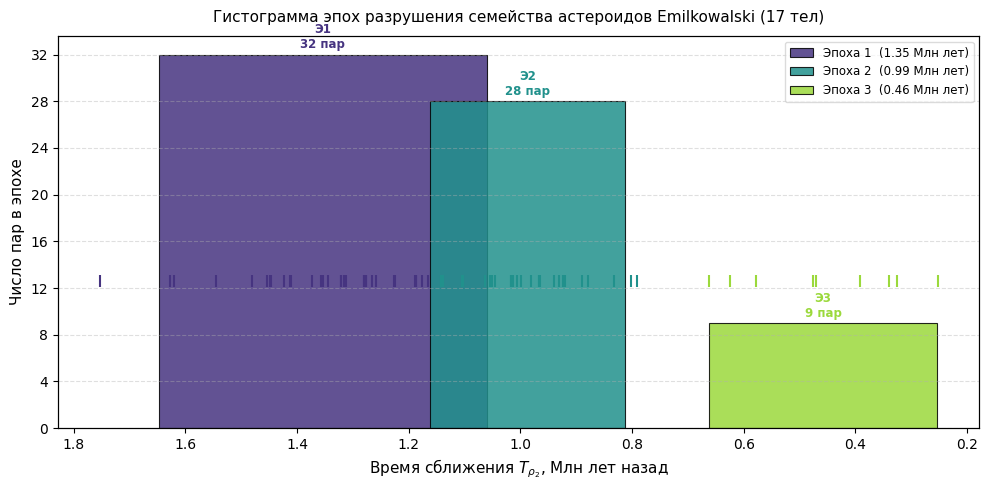

Сохранено: epoch_histogram_17.png


In [67]:
# === Эпохи каскада ===

EPS_T = 1.0   # порог ward-кластеризации 
T_MAX = 1.80  # физический потолок возраста семейства (Kuznetsov2025e)

df_reliable = df_reliable_full.copy()

n_before = len(df_reliable)
df_reliable = df_reliable[df_reliable['T_rho2_Myr'] <= T_MAX].copy().reset_index(drop=True)
print(f"Отброшено пар с T > {T_MAX} Млн лет: {n_before - len(df_reliable)}")

times = df_reliable['T_rho2_Myr'].values.reshape(-1, 1)
Z = linkage(times, method='ward')
df_reliable['epoch_raw'] = fcluster(Z, t=EPS_T, criterion='distance')

# Эпоха 1 = самая древняя (как у Кузнецова)
mean_times = df_reliable.groupby('epoch_raw')['T_rho2_Myr'].mean().sort_values(ascending=False)
remap = {old: new for new, old in enumerate(mean_times.index, start=1)}
df_reliable['epoch'] = df_reliable['epoch_raw'].map(remap)
df_reliable = df_reliable.drop(columns=['epoch_raw'])

rows = []
for ep in sorted(df_reliable['epoch'].unique()):
    sub = df_reliable[df_reliable['epoch'] == ep]
    objs = set()
    for _, r in sub.iterrows():
        objs.update(r['Pair'].split('-'))
    rows.append({
        'epoch':      ep,
        'n_pairs':    len(sub),
        'T_min_Myr':  sub['T_rho2_Myr'].min(),
        'T_max_Myr':  sub['T_rho2_Myr'].max(),
        'T_mean_Myr': sub['T_rho2_Myr'].mean(),
        'T_std_Myr':  sub['T_rho2_Myr'].std() if len(sub) > 1 else 0.0,
        'n_objects':  len(objs),
        'objects':    ', '.join(sorted(objs)),
    })
epoch_df = pd.DataFrame(rows)

print(f"\nЭпох: {len(epoch_df)}  (ward, EPS_T = {EPS_T}, T_MAX = {T_MAX} Млн лет)\n")
print(epoch_df[['epoch', 'n_pairs', 'T_min_Myr', 'T_max_Myr',
                'T_mean_Myr', 'n_objects', 'objects']].to_string(index=False))

# --- Гистограмма эпох ---
cmap_hist = plt.cm.viridis
n_ep_hist = len(epoch_df)

fig_h, ax_h = plt.subplots(figsize=(10, 5))

for _, row in epoch_df.iterrows():
    ep   = int(row['epoch'])
    col  = cmap_hist(0.15 + 0.7 * (ep - 1) / max(n_ep_hist - 1, 1))
    xc   = row['T_mean_Myr']
    half = max((row['T_max_Myr'] - row['T_min_Myr']) / 2, 0.01)
    n_p  = int(row['n_pairs'])
    ax_h.bar(xc, n_p, width=half * 2,
             color=col, edgecolor='black', linewidth=0.8, alpha=0.85,
             label=f"Эпоха {ep}  ({xc:.2f} Млн лет)")
    ax_h.text(xc, n_p + 0.3, f"Э{ep}\n{n_p} пар",
              ha='center', va='bottom', fontsize=8.5, fontweight='bold', color=col)

# Rug plot — тики отдельных пар
ax_h2 = ax_h.twinx()
epoch_color_map = {
    int(r['epoch']): cmap_hist(0.15 + 0.7 * (int(r['epoch']) - 1) / max(n_ep_hist - 1, 1))
    for _, r in epoch_df.iterrows()
}
colors_scatter = [epoch_color_map.get(int(e), 'gray') for e in df_reliable['epoch']]
ax_h2.scatter(df_reliable['T_rho2_Myr'], [-0.25] * len(df_reliable),
              c=colors_scatter, marker='|', s=80, linewidths=1.5, zorder=5)
ax_h2.set_ylim(-1, 1)
ax_h2.set_yticks([])

ax_h.invert_xaxis()
ax_h.set_xlabel("Время сближения $T_{\\rho_2}$, Млн лет назад", fontsize=11)
ax_h.set_ylabel("Число пар в эпохе", fontsize=11)
ax_h.set_title(
    f"Гистограмма эпох разрушения семейства астероидов Emilkowalski (17 тел)",
    fontsize=11, pad=10)
ax_h.legend(loc='upper right', fontsize=8.5, framealpha=0.7)
ax_h.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax_h.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
out_hist = f"epoch_histogram_{N_OBJECTS}.png"
plt.savefig(out_hist, dpi=200, bbox_inches='tight')
plt.show()
print(f"Сохранено: {out_hist}")

## Этап 6. Дерево каскада


In [68]:
# Диаметры эквивалентных сфер, метры (Table 1 и Table 3, Kuznetsov et al. 2025)
DIAMETERS_M = {
    "14627":     7105,
    "126761":    2287,
    "224559":    1795,
    "256124":    2852,
    "434002":    1889,
    "476673":    1500,
    "653857":    1900,
    "679223":    1500,
    "778121":    1700,
    "804185":    2200,
    "2016CS377": 1400,
    "2017UY114": 1200,
    "2022SA160": 1500,
    "2009UL13":  1600,
    "2019VE44":  1400,
    "2020UZ20":  1400,
    "2021TU55":  1500,
}

# === Дерево каскада (критерий родителя — диаметр, как у Кузнецова) ===

G_undir = nx.Graph()
for _, r in df_reliable.iterrows():
    a, b = r['Pair'].split('-')
    G_undir.add_edge(a, b,
                     rho2=r['Min_rho2'], time=r['T_rho2_Myr'],
                     scenario=r['Scenario'], epoch=int(r['epoch']))

if ROOT not in G_undir:
    raise RuntimeError(f"Корень {ROOT} отсутствует в графе надёжных связей")

G_dir = nx.DiGraph()
G_dir.add_node(ROOT)
unreached = []

for x in ASTEROID_IDS:
    if x == ROOT:
        continue
    if x not in G_undir:
        unreached.append(x)
        continue

    # Родитель = сосед с наибольшим диаметром (физически: остаток после откола)
    # При равных диаметрах — минимальный rho2
    neighbors = list(G_undir.neighbors(x))
    if not neighbors:
        unreached.append(x)
        continue

    parent = max(neighbors,
                 key=lambda y: (DIAMETERS_M.get(y, 0), -G_undir[x][y]['rho2']))
    G_dir.add_edge(parent, x, **G_undir[x][parent])

print(f"Дерево: {G_dir.number_of_nodes()} узлов, {G_dir.number_of_edges()} рёбер")
if unreached:
    print(f"Изолированные ({len(unreached)}): {unreached}")

print()
print("Связи (parent → child, по T_rho2):")
for p, c, d in sorted(G_dir.edges(data=True), key=lambda e: e[2]['time'], reverse=True):
    print(f"  {p:<12} → {c:<12}  T = {d['time']:.3f} Млн лет,  "
          f"ρ₂ = {d['rho2']:.5f},  эпоха {d['epoch']},  {d['scenario']}")

Дерево: 17 узлов, 16 рёбер

Связи (parent → child, по T_rho2):
  256124       → 804185        T = 1.545 Млн лет,  ρ₂ = 0.00115,  эпоха 1,  nominal/nominal_plane
  434002       → 126761        T = 1.449 Млн лет,  ρ₂ = 0.00194,  эпоха 1,  nominal/nominal
  256124       → 679223        T = 1.373 Млн лет,  ρ₂ = 0.00040,  эпоха 1,  nominal/nominal_minus
  14627        → 778121        T = 1.358 Млн лет,  ρ₂ = 0.00284,  эпоха 1,  nominal/nominal_plus
  14627        → 2019VE44      T = 1.312 Млн лет,  ρ₂ = 0.00229,  эпоха 1,  nominal/nominal_plus
  14627        → 434002        T = 1.225 Млн лет,  ρ₂ = 0.00285,  эпоха 1,  nominal/nominal
  14627        → 476673        T = 1.188 Млн лет,  ρ₂ = 0.00270,  эпоха 1,  nominal/nominal_plane
  14627        → 2021TU55      T = 1.102 Млн лет,  ρ₂ = 0.00288,  эпоха 2,  nominal/nominal_plane
  256124       → 2009UL13      T = 1.053 Млн лет,  ρ₂ = 0.00368,  эпоха 2,  nominal/nominal_plane
  14627        → 2022SA160     T = 1.051 Млн лет,  ρ₂ = 0.00193,  эпо

In [69]:
# Проверка корректности дерева
cycles = list(nx.simple_cycles(G_dir))
multi_parents = [n for n in G_dir.nodes() if G_dir.in_degree(n) > 1]
print(f"Циклы: {cycles if cycles else 'нет'}")
print(f"Узлы с двумя родителями: {multi_parents if multi_parents else 'нет'}")
print(f"Изолированные (нет родителя, кроме корня): "
      f"{[n for n in ASTEROID_IDS if n != ROOT and G_dir.in_degree(n) == 0]}")

Циклы: нет
Узлы с двумя родителями: нет
Изолированные (нет родителя, кроме корня): []


## Этап 7. Выгрузка таблиц для диплома

Имена выходных файлов содержат `N_OBJECTS`, чтобы результаты для 17 и 18 не перетирали друг друга.

- **`pair_summary_{N}.csv`** (раздел 4.2) — все уникальные пары, по строке на пару, с моментами $T_{\rho_2}$, $T_{\Delta\Omega,\Delta\omega}$, $\Delta T$, $\rho_{2,\min}$, $f_{\min}$ и флагом надёжности.
- **`axis_assignment_{N}.csv`** (раздел 4.4) — финальная ось на объект.
- **`cascade_tree_{N}.csv`** (раздел 4.4) — рёбра дерева.
- **`epochs_summary_{N}.csv`** (разделы 4.3–4.4) — сводка по эпохам.


In [70]:
# === Выгрузка результатов ===

# 1. Сводка по парам — раздел 4.2
pair_summary = df_final[['pair_key', 'Pair', 'Scenario',
                         'T_rho2_Myr', 'T_angles_Myr', 'Delta_T',
                         'Min_rho2', 'f_min_angle',
                         'is_valid', 'reliable']].copy()
pair_summary.to_csv(f"pair_summary_{N_OBJECTS}.csv", index=False)

# 2. Назначение осей — раздел 4.4
axis_df = pd.DataFrame([
    {'object': oid,
     'axis_scenario': chosen_axes.get(oid, 'НЕ НАЗНАЧЕНА'),
     'axis_label':    AXIS_LABEL.get(chosen_axes.get(oid, ''), '?'),
     'is_fixed':      oid in FIXED_IDS}
    for oid in ASTEROID_IDS
])
axis_df.to_csv(f"axis_assignment_{N_OBJECTS}.csv", index=False)

# 3. Дерево каскада — раздел 4.4
tree_rows = [{
    'parent': p, 'child': c,
    'T_rho2_Myr': d['time'], 'Min_rho2': d['rho2'],
    'epoch': d['epoch'], 'scenario': d['scenario']
} for p, c, d in G_dir.edges(data=True)]
tree_df = (pd.DataFrame(tree_rows)
             .sort_values(['epoch', 'T_rho2_Myr'])
             .reset_index(drop=True))
tree_df.to_csv(f"cascade_tree_{N_OBJECTS}.csv", index=False)

# 4. Сводка по эпохам — разделы 4.3, 4.4
epoch_df.to_csv(f"epochs_summary_{N_OBJECTS}.csv", index=False)

print("Сохранены:")
print(f"  pair_summary_{N_OBJECTS}.csv     : {len(pair_summary)} строк")
print(f"  axis_assignment_{N_OBJECTS}.csv  : {len(axis_df)} объектов")
print(f"  cascade_tree_{N_OBJECTS}.csv     : {len(tree_df)} рёбер")
print(f"  epochs_summary_{N_OBJECTS}.csv   : {len(epoch_df)} эпох")


Сохранены:
  pair_summary_17.csv     : 136 строк
  axis_assignment_17.csv  : 17 объектов
  cascade_tree_17.csv     : 16 рёбер
  epochs_summary_17.csv   : 3 эпох


## Визуализация

Дерево каскада на временной шкале (ось X — $T_{\rho_2}$ в Млн лет назад, инвертирована). Эпохи — цветные фоновые полосы. Жёлтые узлы — фиксированные объекты (`14627`, `126761`, `224559`, `256124`, `434002`).


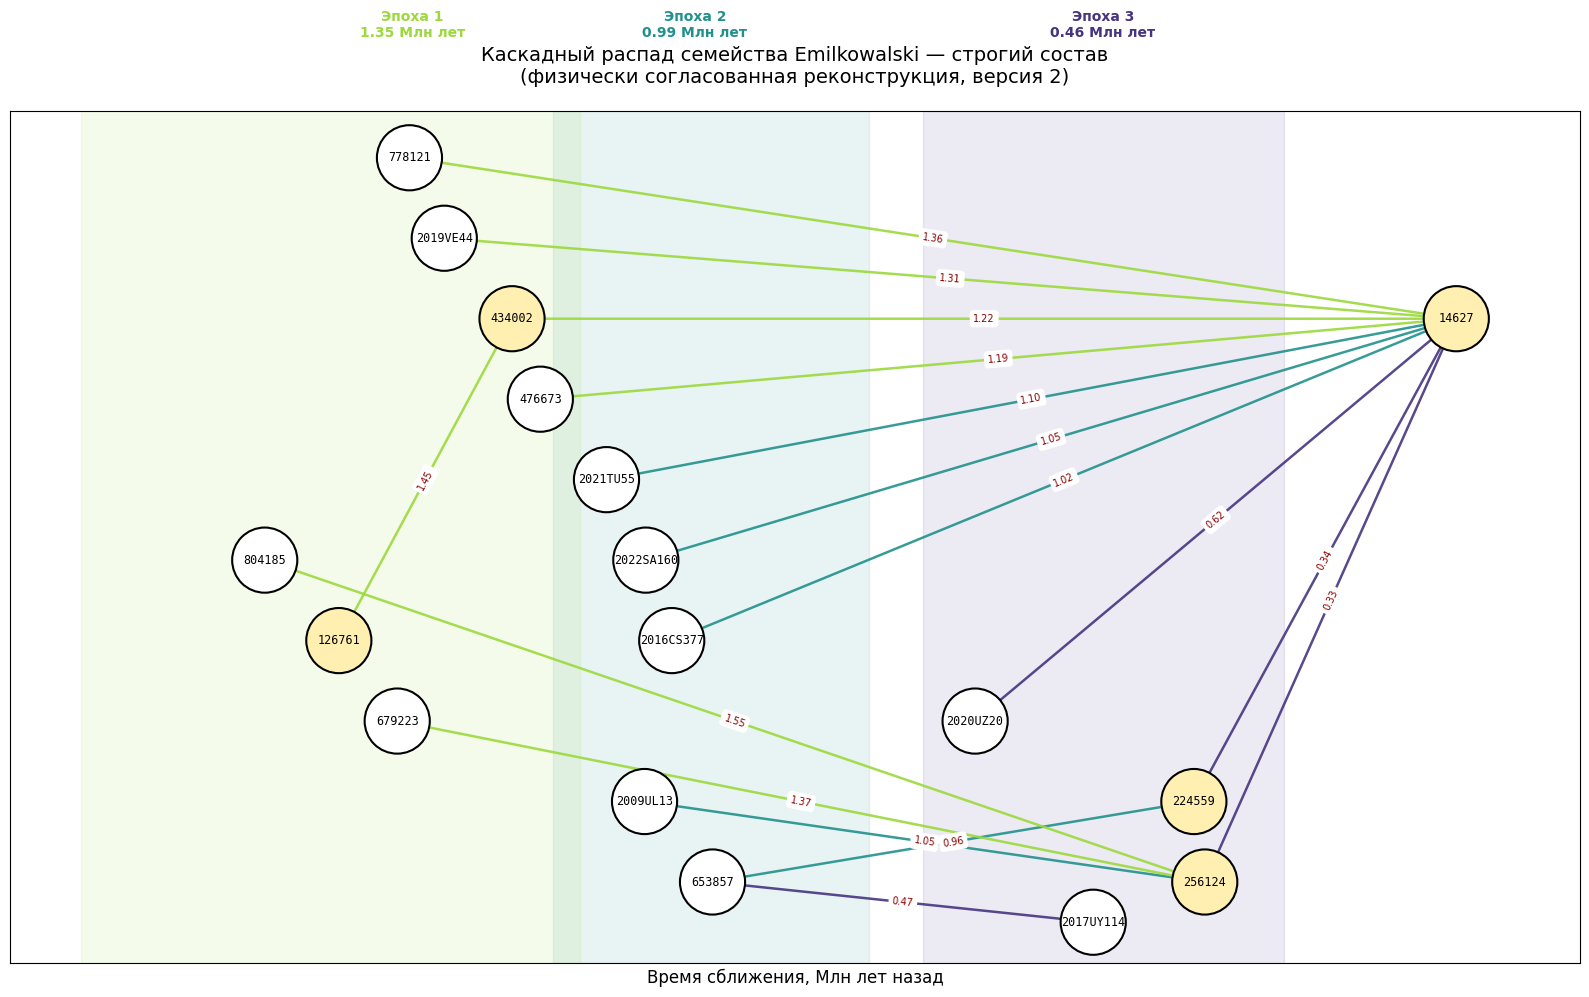

Сохранено: cascade_tree_v2_17.png


In [72]:
# === Визуализация ===
if G_dir.number_of_edges() == 0:
    print("Нечего рисовать — дерево пусто.")
else:
    fig, ax = plt.subplots(figsize=(16, 10))
    # Раскладка: уровень = глубина BFS от ROOT, X = время входящего ребра
    depth = {ROOT: 0}
    for parent, child in nx.bfs_edges(G_dir, ROOT):
        depth[child] = depth[parent] + 1
    def t_in(n):
        if n == ROOT:
            return 0.0
        preds = list(G_dir.predecessors(n))
        return G_dir[preds[0]][n]['time'] if preds else 0.0
    nodes_by_depth = {}
    for node, d in depth.items():
        nodes_by_depth.setdefault(d, []).append(node)
    pos = {}
    for d, nodes in nodes_by_depth.items():
        nodes_sorted = sorted(nodes, key=t_in)
        n = len(nodes_sorted)
        for i, node in enumerate(nodes_sorted):
            pos[node] = (t_in(node), -d * 2.0 + (i - (n - 1) / 2) * 0.8)
    # Цвета эпох — в обратном порядке (эпоха 1 = самая старая = правее на инвертированной оси)
    if len(epoch_df) > 0:
        n_ep = max(epoch_df['epoch'])
        cmap = plt.cm.viridis
        # Переворачиваем порядок цветов: эпоха с наибольшим номером получает цвет начала палитры
        epoch_colors = {ep: cmap(0.15 + 0.7 * (n_ep - ep) / max(n_ep - 1, 1))
                        for ep in sorted(epoch_df['epoch'])}
    else:
        epoch_colors = {}
    # Фоновые полосы эпох — итерируем в обратном порядке по убыванию номера эпохи
    if pos:
        y_max = max(p[1] for p in pos.values()) + 1.2
        for _, ep_row in epoch_df.sort_values('epoch', ascending=False).iterrows():
            ax.axvspan(ep_row['T_min_Myr'] - 0.03, ep_row['T_max_Myr'] + 0.03,
                       alpha=0.10, color=epoch_colors.get(ep_row['epoch'], 'gray'))
            ax.text(ep_row['T_mean_Myr'], y_max,
                    f"Эпоха {int(ep_row['epoch'])}\n{ep_row['T_mean_Myr']:.2f} Млн лет",
                    ha='center', fontsize=10, fontweight='bold',
                    color=epoch_colors.get(ep_row['epoch'], 'black'))
    # Узлы
    fixed_set = set(FIXED_IDS)
    node_colors = ['#ffefb0' if n in fixed_set else 'white' for n in G_dir.nodes()]
    nx.draw_networkx_nodes(G_dir, pos, node_size=2200,
                           node_color=node_colors, edgecolors='black',
                           linewidths=1.5, ax=ax)
    nx.draw_networkx_labels(G_dir, pos, font_size=8.5,
                            font_family='monospace', ax=ax)
    # Рёбра — цвет по эпохе
    for p, c, d in G_dir.edges(data=True):
        col = epoch_colors.get(d['epoch'], 'gray')
        nx.draw_networkx_edges(G_dir, pos, edgelist=[(p, c)],
                               arrowstyle='-|>', arrowsize=22,
                               edge_color=[col], width=1.8, alpha=0.9, ax=ax)
    edge_labels = {(p, c): f"{d['time']:.2f}" for p, c, d in G_dir.edges(data=True)}
    nx.draw_networkx_edge_labels(G_dir, pos, edge_labels=edge_labels,
                                 font_color='darkred', font_size=7,
                                 label_pos=0.5, ax=ax)
    ax.invert_xaxis()
    ax.set_xlabel("Время сближения, Млн лет назад", fontsize=12)
    ax.set_yticks([])
    title_suffix = "строгий состав" if N_OBJECTS == 17 else f"состав {N_OBJECTS} объектов"
    ax.set_title(f"Каскадный распад семейства Emilkowalski — {title_suffix}\n"
                 "(физически согласованная реконструкция, версия 2)",
                 fontsize=14, pad=20)
    ax.grid(False)
    plt.tight_layout()
    out_png = f"cascade_tree_v2_{N_OBJECTS}.png"
    plt.savefig(out_png, dpi=200, bbox_inches='tight')
    plt.show()
    print(f"Сохранено: {out_png}")

## Сравнение 17 vs 18 объектов

После прогона обоих вариантов имеет смысл сопоставить:

| Что сравниваем | Признак влияния `2014WE584` |
|---|---|
| `axis_assignment_17.csv` vs `axis_assignment_18.csv` | Меняется ли назначенная ось хоть для одного объекта? |
| `cascade_tree_17.csv` vs `cascade_tree_18.csv` | Меняется ли структура дерева для общих 17 объектов? |
| `epochs_summary_17.csv` vs `epochs_summary_18.csv` | Меняются ли средние времена эпох? |

Если результаты совпадают на общих 17 объектах при добавлении `2014WE584` — это аргумент за устойчивость реконструкции и за то, что объект может быть частью семейства, несмотря на провал по HCM.

## Параметры, которые имеет смысл крутить

| Параметр | Значение | Что меняет |
|---|---|---|
| `RHO2_MAX` | 0.05 | Жёсткость порога метрики Холшевникова. |
| `F_MIN_MAX` | 0.4° | Порог сглаженного $f(-T)$. Стандарт Pravec et al. (2018). |
| `DELTA_T_MAX` | 0.1 Млн лет | Согласованность $T_{\rho_2}$ vs $T_{\Delta\Omega,\Delta\omega}$. |
| `EPS_T` | 0.15 Млн лет | Ширина склейки эпох. Меньше → больше эпох. |

## Связь с разделами диплома

- **4.1** — состав семейства (это уже сделано в `Emilkowalski_f.ipynb`).
- **4.2** — `pair_summary_{N}.csv` + раздел про парные сближения.
- **4.3** — `epochs_summary_{N}.csv` + анализ $\Delta T$ и $\rho_{2,\min}$.
- **4.4** — `axis_assignment_{N}.csv` + `cascade_tree_{N}.csv` + `cascade_tree_v2_{N}.png`.
